# Structure-Based Bioactivity Grading - Third Phase

Small-scale docking validation of the ML-QSAR selected compounds.

Runs locally on a personal computer (<20min runtime, 80 compounds).

**Inputs:**
- `Imidazolones_30samples.csv` (ID, SMILES, QSAR_score)
- `Thiazolones_15samples.csv` (ID, SMILES, QSAR_score)
- `6COX.pdb` (COX-2, ligand S58)
- `3KK6.pdb` (COX-1, ligand FLC)

**Workflow:**
1. **PREPARE** — Ligand (multi-conformer) + receptor preparation
2. **DOCK** — AutoDock Vina (exhaustiveness=16, num_modes=3)
3. **SCORE** — Geometric scoring, pose selection, final ranking

***(Please read [the third phase README.md](03_docking_pdbqts_data/README.md) for full details on this notebook).***


In [1]:
import sys
import pandas as pd

sys.path.insert(0, "03_docking_pdbqts_data")
from modules import docking as dock

cfg = dock.get_docking_config()
dirs = dock.init_hpc_dirs(
    cfg["ROOT"] / "03_docking_pdbqts_data/.interim",
    receptor_ids=["6COX", "3KK6"],
)

[init_hpc_dirs] Created 7 directories under 03_docking_pdbqts_data/.interim


## 📥 17. Load input compounds

Load the QSAR-prioritized compounds from file.
Thiazolones and imidazolones are loaded separately then concatenated.


In [2]:
df_ligands_raw = dock.load_ligands([
    cfg["INPUT_CSV_THIAZOLONES"],
    cfg["INPUT_CSV_IMIDAZOLONES"],
])
display(df_ligands_raw[["ID", "SMILES", "QSAR_score"]].head())

[Load ligands] 80 compounds total


,ID,SMILES,QSAR_score
0,A40C14S,COc1ccc(/C=C2\N=C(c3ccnc4ccccc34)SC2=O)c(OC)c1OC,8.110302
1,A60C24S,COc1ccccc1/C=C1\N=C(c2c(F)cccc2Br)SC1=O,8.163366
2,A89C27S,C=C(C)/C=C1\N=C(c2ccccn2)SC1=O,7.914900
3,A47C32S,COc1ccc(C2=N/C(=C\c3cccnc3)C(=O)S2)c(Br)c1,8.151053
4,A34C7S,COc1ccc(C2=N/C(=C\c3ccc[nH]3)C(=O)S2)cc1OC,7.843126


## ⬥ 18. Prepare ligands (multi-conformer)

Generate RDKit multi-conformer structures for flexible docking.


In [3]:
df_ligands = dock.prepare_ligands_multi_conf(
    df_ligands_raw, dirs["ligands"], n_confs=15, seed=42,
)

[prepare_ligands_multi_conf] 80/80 ligands prepared successfully


## ⬥ 19. Prepare receptors

Prepare COX-2 (6COX) and COX-1 (3KK6) with binding site boxes.


In [4]:
cox2_info, cox1_info = dock.prepare_all_receptors(dirs, cfg)

[prepare_receptor] Generated 03_docking_pdbqts_data/.interim/receptors/6COX.pdbqt
[prepare_receptor] Using overridden box for 6COX: center=[26.5, 23.5, 48.3]
[prepare_receptor] Saved 03_docking_pdbqts_data/.interim/receptors/6COX_box.json
[prepare_receptor] Generated 03_docking_pdbqts_data/.interim/receptors/3KK6.pdbqt
[get_binding_site_center] Using FLC centroid from 3KK6.pdb
[prepare_receptor] Saved 03_docking_pdbqts_data/.interim/receptors/3KK6_box.json

6COX:
  Center: (26.5, 23.5, 48.3)
  Size: 22.0 x 22.0 x 22.0 A

3KK6:
  Center: (-41.061, 66.59, -1.471)
  Size: 22.0 x 22.0 x 22.0 A


## 🔹 20. Run docking

Create ligand–receptor mapping and run AutoDock Vina locally.


In [5]:
mapping_df, docking_stats = dock.run_docking_workflow(
    df_ligands, dirs, exhaustiveness=16, num_modes=3, seed=42,
)

[write_mapping_csv] 160 docking tasks written to 03_docking_pdbqts_data/.interim/mapping.csv
[docking mapping] 160 tasks
[docking] Using Vina at: vina
  [1/160] A40C14S x 6COX done
  [2/160] A40C14S x 3KK6 done
  [3/160] A60C24S x 6COX done
  [4/160] A60C24S x 3KK6 done
  [5/160] A89C27S x 6COX done
  [6/160] A89C27S x 3KK6 done
  [7/160] A47C32S x 6COX done
  [8/160] A47C32S x 3KK6 done
  [9/160] A34C7S x 6COX done
  [10/160] A34C7S x 3KK6 done
  [11/160] A42C30S x 6COX done
  [12/160] A42C30S x 3KK6 done
  [13/160] A70C29S x 6COX done
  [14/160] A70C29S x 3KK6 done
  [15/160] A78C7S x 6COX done
  [16/160] A78C7S x 3KK6 done
  [17/160] A70C39S x 6COX done
  [18/160] A70C39S x 3KK6 done
  [19/160] A13C37S x 6COX done
  [20/160] A13C37S x 3KK6 done
  [21/160] A47C2N37 x 6COX done
  [22/160] A47C2N37 x 3KK6 done
  [23/160] A17C39N37 x 6COX done
  [24/160] A17C39N37 x 3KK6 done
  [25/160] A17C26N32 x 6COX done
  [26/160] A17C26N32 x 3KK6 done
  [27/160] A94C10N1 x 6COX done
  [28/160] A94

## ⬥ 21. Validate and parse results

Check docking completion and extract all ligand poses.


In [6]:
df_all_poses = dock.validate_and_extract(
    dirs, ["6COX", "3KK6"], cfg["RECEPTOR_MAP"], num_modes=3,
)
if not df_all_poses.empty:
    display(df_all_poses.head(10))

[validate_docking] PARTIAL: 80/160 docking tasks validated. Missing: 80, Failed: 0, Orphaned: 0 | Missing tasks: [('A47C35N33', '3KK6'), ('A34C9N34', '3KK6'), ('A17C15N5', '3KK6'), ('A86C14N42', '3KK6'), ('A9C12N48', '3KK6')]...
[validate_docking] PARTIAL: 80/160 docking tasks validated. Missing: 80, Failed: 0, Orphaned: 0 | Missing tasks: [('A34C8N36', '6COX'), ('A30C32N24', '6COX'), ('A100C26N33', '6COX'), ('A42C43N37', '6COX'), ('A63C9N53', '6COX')]...

Partial results: 160/320 tasks validated.
Downstream analysis will use only validated tasks.
[parse poses] 477 poses extracted (3 per task max)


,ligand_id,receptor_id,cox_label,pose_rank,docking_score
0,A45C43N59,6COX,COX2,1,-6.27
1,A45C43N59,6COX,COX2,2,-6.26
2,A45C43N59,6COX,COX2,3,-5.81
3,A17C39N37,6COX,COX2,1,-8.02
4,A17C39N37,6COX,COX2,2,-7.06
5,A17C39N37,6COX,COX2,3,-6.22
6,A47C35N33,6COX,COX2,1,-7.24
7,A47C35N33,6COX,COX2,2,-6.76
8,A47C35N33,6COX,COX2,3,16.50
9,A18C43N46,6COX,COX2,1,-7.54


## 🔸 22. Geometric scoring and pose selection

Select the best pose per compound using geometric criteria.


In [7]:
df_best_poses = dock.select_best_poses_across(
    df_all_poses, dirs, ["6COX", "3KK6"], cfg["receptor_pdb_map"],
)
if not df_best_poses.empty:
    display(df_best_poses.head(10))

    Arg120: interaction 2.69 A (+2)
    Tyr355: interaction 2.82 A (+2)
    Side pocket: fraction=0.40 (+1)
    Clashes: 50 (running score: 3.0)
    Arg120: interaction 2.69 A (+2)
    Tyr355: interaction 2.82 A (+2)
    Side pocket: fraction=0.40 (+1)
    Clashes: 50 (running score: 3.0)
    Arg120: interaction 2.69 A (+2)
    Tyr355: interaction 2.82 A (+2)
    Side pocket: fraction=0.40 (+1)
    Clashes: 50 (running score: 3.0)
    Arg120: interaction 2.69 A (+2)
    Tyr355: interaction 3.12 A (+2)
    Side pocket: fraction=0.68 (+1)
    Clashes: 69 (running score: 3.0)
    Arg120: interaction 2.69 A (+2)
    Tyr355: interaction 3.12 A (+2)
    Side pocket: fraction=0.68 (+1)
    Clashes: 69 (running score: 3.0)
    Arg120: interaction 2.69 A (+2)
    Tyr355: interaction 3.12 A (+2)
    Side pocket: fraction=0.68 (+1)
    Clashes: 69 (running score: 3.0)
    Arg120: interaction 2.78 A (+2)
    Tyr355: interaction 2.92 A (+2)
    Side pocket: fraction=0.50 (+1)
    Clashes: 29 (runni

,ligand_id,receptor_id,cox_label,best_pose_rank,docking_score,geometric_score
0,A45C43N59,6COX,COX2,1,-6.27,3.0
1,A17C39N37,6COX,COX2,1,-8.02,3.0
2,A47C35N33,6COX,COX2,1,-7.24,3.0
3,A18C43N46,6COX,COX2,1,-7.54,3.0
4,A30C14N42,6COX,COX2,1,-5.58,3.0
5,A17C3N24,6COX,COX2,1,-8.38,3.0
6,A17C9N55,6COX,COX2,1,-7.05,3.0
7,A17C38N48,6COX,COX2,1,-9.53,3.0
8,A92C8N24,6COX,COX2,1,-7.43,3.0
9,A94C9N55,6COX,COX2,1,-7.47,3.0


## ⬥ 24. Final ranking

Combine QSAR scores with docking scores into a unified ranking.


In [8]:
df_ranked = dock.compute_final_ranking(df_best_poses, df_ligands_raw)
if not df_ranked.empty:
    cols = ["ligand_id", "QSAR_score", "score_cox2", "score_cox1",
            "geometric_score", "final_score"]
    display(df_ranked[[c for c in cols if c in df_ranked.columns]].round(4))

[compute_final_ranking] Scores computed for 80 compounds
[compute_final_ranking] Formula: final_score = 0.5*qsar_norm + 0.4*geo_norm + 0.1*vina_norm


,ligand_id,QSAR_score,score_cox2,score_cox1,final_score
0,A60C24S,8.1634,-6.92,-7.37,0.8956
1,A40C14S,8.1103,-6.38,-7.35,0.8949
2,A42C30S,7.8816,-9.45,-8.52,0.8241
3,A70C29S,7.9440,-8.07,-7.76,0.7937
4,A47C32S,8.1511,-7.89,-7.60,0.7766
...,...,...,...,...,...
75,A73C12N17,10.6551,-9.05,-9.70,0.1734
76,A13C37S,8.7972,-5.90,-7.89,0.1582
77,A34C8N36,10.2010,-8.17,-7.96,0.1519
78,A64C43N19,10.4003,-8.98,-8.26,0.1481


## 📤 25. Output

Save the ranked scores and poses.


In [9]:
dock.save_all_outputs(
    df_ranked, dirs,
    cfg["ROOT"] / "03_docking_pdbqts_data/outputs",
)

[save_docking_scores] Saved 80 entries to 03_docking_pdbqts_data/outputs/docking_scores.csv
[poses] Poses saved to 03_docking_pdbqts_data/outputs/poses


## 🖼️ 26. Visualization (optional)

Render top-ranked poses with PyMOL.


[visualization] Rendering top 5 compounds (6COX)
[visualization] #1 A60C24S: saved A60C24S_6COX.png


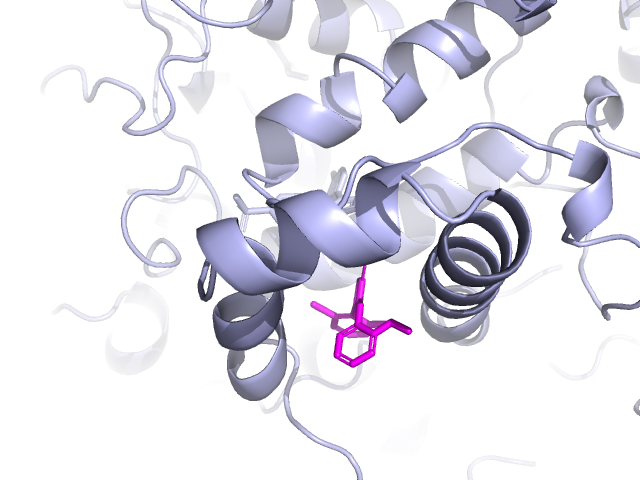

[visualization] #2 A40C14S: saved A40C14S_6COX.png


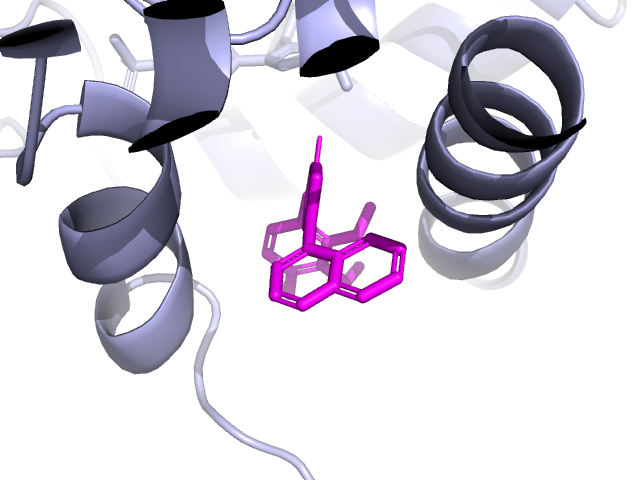

[visualization] #3 A42C30S: saved A42C30S_6COX.png


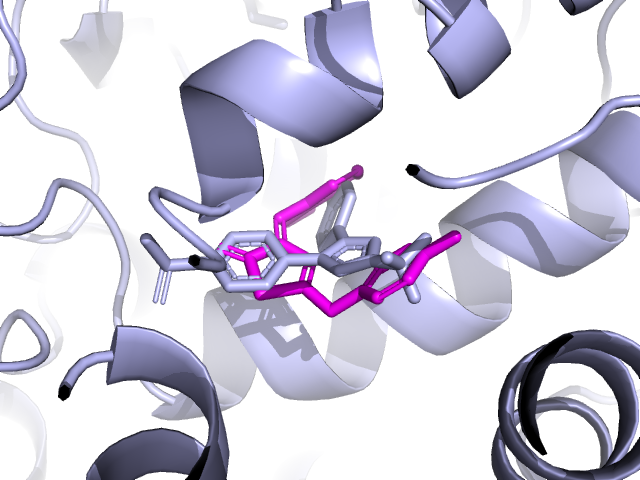

[visualization] #4 A70C29S: saved A70C29S_6COX.png


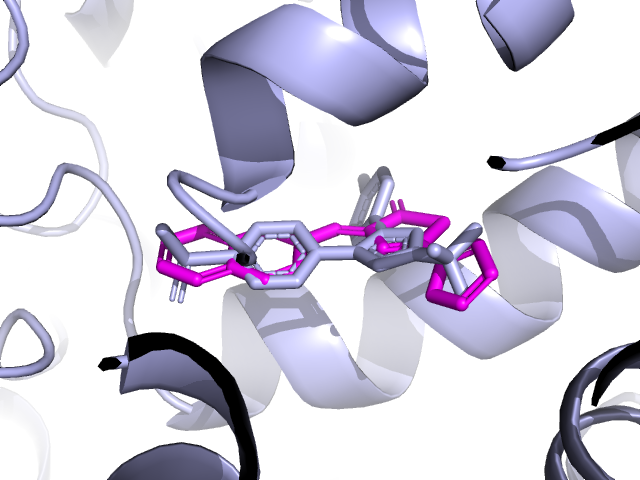

[visualization] #5 A47C32S: saved A47C32S_6COX.png


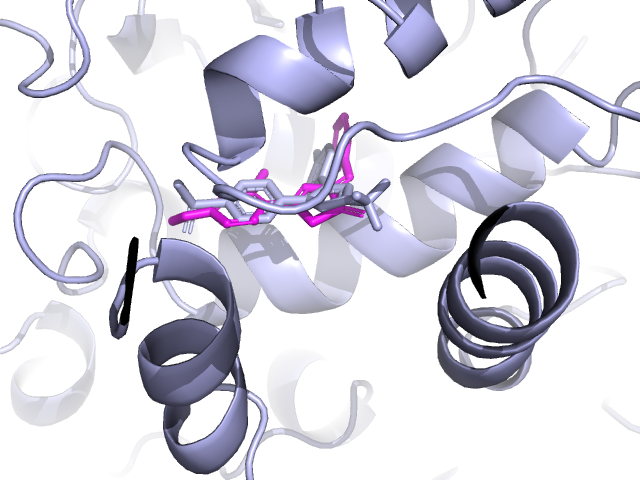

In [10]:
dock.render_top_poses(
    df_ranked, dirs, receptor_id="6COX",
    receptor_pdb=cfg["COX2_PDB"],
    output_dir=cfg["ROOT"] / "03_docking_pdbqts_data/outputs/figures",
    top_n=5,
)